In [1]:
# Import necessary libraries
import torch
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, random_split
import os
import numpy as np
from PIL import Image
from collections import Counter
import lightning as L
from torchmetrics.classification import Accuracy
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import EarlyStopping

In [15]:
# --- 1. Revised Model Architecture ---
# Based on the paper's description and diagram[cite: 189, 384].
# Key changes: Added U-Net style skip connections and adjusted decoder to match the diagram.
class ConVAT(nn.Module):
    def __init__(self, in_channels=1, num_classes=8):
        """
        Revised implementation of the ConVAT model architecture.
        This version more closely follows the U-Net-like structure with skip connections
        implied by the diagram in the paper.

        Args:
            in_channels (int): Number of input channels (1 for grayscale, 3 for color).
            num_classes (int): Number of output classes for classification.
        """
        super(ConVAT, self).__init__()

        # --- ENCODER ---
        # Extracts hierarchical features from the input image.

        # Input: 256x256
        self.enc1 = self.conv_block(in_channels, 32, 64)   # Encoder block 1
        self.pool1 = nn.MaxPool2d(2, 2)

        self.enc2 = self.conv_block(64, 128)               # Encoder block 2
        self.pool2 = nn.MaxPool2d(2, 2)

        # --- BOTTLENECK with VARIATIONAL ATTENTION ---
        # The deepest part of the network where the attention mechanism is applied.
        self.bottleneck_conv = nn.Conv2d(128, 256, kernel_size=3, padding=1) # As per diagram showing deeper features before attention
        self.relu = nn.ReLU(inplace=True)

        self.attention = nn.MultiheadAttention(embed_dim=256, num_heads=8, batch_first=True) # [cite: 185]
        self.squeeze = nn.AdaptiveAvgPool2d(1) # [cite: 233]

        # --- DECODER ---
        # Reconstructs spatial information using features from the encoder (skip connections).

        self.upconv1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(256, 128, 64) # Input channels = 128 (from upconv) + 128 (from enc2 skip)

        self.upconv2 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(96, 64, 32)  # Input channels = 32 (from upconv) + 64 (from enc1 skip)

        # --- CLASSIFICATION HEAD ---
        # Fully connected layers for the final classification task.
        self.dense1 = nn.Linear(256, 1024)
        self.dropout1 = nn.Dropout(0.5)

        self.dense2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)
        self.dropout2 = nn.Dropout(0.5)

        self.output_dense = nn.Linear(512, num_classes)

        # --- SEGMENTATION HEAD (as shown in diagram) ---
        # Final convolution to produce a segmentation map.
        self.final_conv = nn.Conv2d(32, 1, kernel_size=1) # [cite: 328]
        self.sigmoid_out = nn.Sigmoid() # [cite: 328]


    def conv_block(self, in_channels, *filters):
        """Helper to create a sequence of Conv2D and ReLU layers."""
        layers = []
        current_channels = in_channels
        for f in filters:
            layers.append(nn.Conv2d(current_channels, f, kernel_size=3, padding=1))
            layers.append(nn.ReLU(inplace=True))
            current_channels = f
        return nn.Sequential(*layers)

    def forward(self, x):
        # --- ENCODER PATH ---
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # --- BOTTLENECK & ATTENTION ---
        bottleneck = self.relu(self.bottleneck_conv(p2))

        batch_size, channels, height, width = bottleneck.shape
        attn_input = bottleneck.view(batch_size, channels, -1).permute(0, 2, 1) # Reshape for MHA
        attn_output, _ = self.attention(attn_input, attn_input, attn_input)
        attn_output = attn_output.permute(0, 2, 1).view(batch_size, channels, height, width) # Reshape back

        # --- CLASSIFICATION PATH ---
        squeezed = self.squeeze(attn_output)
        squeezed = squeezed.view(batch_size, -1)

        d1 = self.dropout1(self.relu(self.dense1(squeezed)))
        d2_in = self.dense2(d1)
        d2 = self.dropout2(self.relu(self.bn2(d2_in)))
        class_output = self.output_dense(d2) # No softmax here

        # --- DECODER PATH (with skip connections) ---
        u1 = self.upconv1(attn_output)
        # Concatenate skip connection from encoder 2
        merged1 = torch.cat([u1, e2], dim=1)
        d1_dec = self.dec1(merged1)

        u2 = self.upconv2(d1_dec)
        # Concatenate skip connection from encoder 1
        merged2 = torch.cat([u2, e1], dim=1)
        d2_dec = self.dec2(merged2)

        # The paper's architecture diagram also includes a segmentation output.
        # While the main task is classification, we can compute it to fully match the diagram.
        seg_output = self.sigmoid_out(self.final_conv(d2_dec))

        # The primary return value is for the classification task.
        return class_output

In [16]:
class MicroExpClassifier(L.LightningModule):
    def __init__(self, model: nn.Module, lr: float = 1e-3, num_classes: int = 8):
        super().__init__()
        self.model = model
        self.lr = lr
        self.criterion = nn.CrossEntropyLoss()
        self.save_hyperparameters(ignore=['model'])

        self.train_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.val_acc = Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = Accuracy(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        data, targets = batch
        scores = self(data)
        loss = self.criterion(scores, targets)

        # log metric
        self.train_acc.update(scores, targets)
        self.log("train_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log("train_acc", self.train_acc, prog_bar=True, on_epoch=True, on_step=False)

        return loss

    def validation_step(self, batch, batch_idx):
        data, targets = batch
        scores = self(data)
        loss = self.criterion(scores, targets)

        self.val_acc.update(scores, targets)
        self.log("val_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log("val_acc", self.val_acc, prog_bar=True, on_epoch=True, on_step=False)

    def test_step(self, batch, batch_idx):
        data, targets = batch
        scores = self(data)
        loss = self.criterion(scores, targets)

        self.test_acc.update(scores, targets)
        self.log("test_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log("test_acc", self.test_acc, prog_bar=True, on_epoch=True, on_step=False)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.1,
            patience=5,
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
            },
        }


In [17]:
# Replace your previous SAMM_Dataset class with this updated version.

def get_subject_id_from_path(path):
    """
    Helper function to extract the subject ID from a file path.
    Assumes the format 'subXX_...' where 'subXX' is the ID.

    Args:
        path (str): The file path of the image.

    Returns:
        str: The extracted subject ID (e.g., 'sub01').
    """
    try:
        # Get the base filename and split by the first underscore
        return os.path.basename(path).split('_')[0]
    except IndexError:
        # Return a default if the format is unexpected
        return 'unknown'

class SAMM_Dataset(Dataset):
    """
    Custom Dataset class for the SAMM micro-expression dataset.
    This class scans a directory, loads image paths, labels, and subject IDs.
    """
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (str): The root directory of the SAMM dataset (e.g., '.../SAMM_v1/').
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        # Get a sorted list of class names (the subdirectories)
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.subjects = set()

        # Create a mapping from class name (e.g., 'Anger') to a numeric label (e.g., 0)
        for i, class_name in enumerate(self.classes):
            self.class_to_idx[class_name] = i

        # Iterate through each class directory to gather image paths, labels, and subject IDs
        for class_name in self.classes:
            class_idx = self.class_to_idx[class_name]
            class_dir = os.path.join(root_dir, class_name)

            for file_name in sorted(os.listdir(class_dir)):
                # Ensure we are only processing image files
                if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(class_dir, file_name)
                    subject_id = get_subject_id_from_path(img_path)

                    self.samples.append((img_path, class_idx, subject_id))
                    self.subjects.add(subject_id)

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Fetches a single sample from the dataset.

        Args:
            idx (int): The index of the sample to fetch.

        Returns:
            tuple: (image, label) where image is the transformed image tensor.
        """
        # Get the image path, label, and subject ID for the given index
        img_path, label, subject_id = self.samples[idx]

        # Open the image and convert it to grayscale ('L') as required by the model (in_channels=1)
        image = Image.open(img_path).convert('L')

        # Apply transformations if they are defined
        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
# --- Training Parameters ---
ROOT_DIR = "SAMM/SAMM_v1"

# These parameters are based on the experimental setup in the paper[cite: 335, 343, 344].
LEARNING_RATE = 0.001
BATCH_SIZE = 16
EPOCHS = 30 # The paper uses different epochs for each dataset (15 for SAMM, 25 for CASME II, 35 for SMIC) [cite: 342]
NUM_CLASSES = 8 # Example, adjust based on the dataset (SAMM: 8, CASME II: 7, SMIC: 3) [cite: 173]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = 6

In [19]:
# --- Data Augmentation and Transforms ---

train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [20]:
# Create two versions of the dataset: one for training (with augmentation) and one for validation/testing
train_full_dataset = SAMM_Dataset(root_dir=ROOT_DIR, transform=train_transforms)
val_test_full_dataset = SAMM_Dataset(root_dir=ROOT_DIR, transform=val_test_transforms)

NUM_CLASSES = len(train_full_dataset.classes)
print(f"Number of classes detected: {NUM_CLASSES}")

Number of classes detected: 8


In [21]:
# --- Model Initialization ---
model = ConVAT(in_channels=1, num_classes=NUM_CLASSES).to(DEVICE)
print("\nConVAT Model Architecture:")
print(model)


ConVAT Model Architecture:
ConVAT(
  (enc1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck_conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU(inplace=True)
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (squeeze): AdaptiveAvgPool2d(output_size=1)
  (upconv1): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
  (dec1): Sequential(
    (0): Conv2d(256, 128, kernel_size=

In [22]:
# Get all indices and labels for stratified splitting
all_indices = list(range(len(train_full_dataset)))
all_labels = [train_full_dataset.samples[i][1] for i in all_indices]

# Stratified split to maintain class distribution across sets
train_idx, temp_idx, _, _ = train_test_split(
    all_indices, all_labels, test_size=0.3, stratify=all_labels, random_state=42
)

val_idx, test_idx, _, _ = train_test_split(
    temp_idx, [all_labels[i] for i in temp_idx], test_size=0.5, stratify=[all_labels[i] for i in temp_idx], random_state=42
)

# Create subsets for training, validation, and testing
# Training subset uses the augmented dataset
train_subset = Subset(train_full_dataset, train_idx)

# Validation and testing subsets use the non-augmented dataset
valid_subset = Subset(val_test_full_dataset, val_idx)
test_subset  = Subset(val_test_full_dataset, test_idx)

print(f"Training samples: {len(train_subset)}")
print(f"Validation samples: {len(valid_subset)}")
print(f"Testing samples: {len(test_subset)}")

Training samples: 8205
Validation samples: 1758
Testing samples: 1759


In [23]:
# --- WeightedRandomSampler for Imbalanced Data ---
# This part of your code is excellent and should be kept.
train_labels = [all_labels[i] for i in train_subset.indices]
class_counts = Counter(train_labels)
print(f"Class distribution in training set: {sorted(class_counts.items())}")

class_weights = 1.0 / torch.tensor([class_counts[i] for i in range(NUM_CLASSES)], dtype=torch.float)
samples_weight = torch.tensor([class_weights[label] for label in train_labels])
train_sampler = WeightedRandomSampler(samples_weight, num_samples=len(samples_weight), replacement=True)

Class distribution in training set: [(0, 2915), (1, 627), (2, 466), (3, 374), (4, 1356), (5, 1450), (6, 274), (7, 743)]


In [24]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, drop_last=True)
valid_loader = DataLoader(valid_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)
test_loader  = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=True)

Distribusi label di training set: Counter({0: 2915, 5: 1450, 4: 1356, 7: 743, 1: 627, 2: 466, 3: 374, 6: 274})
Class 0: 2915 (35.53%)
Class 6: 274 (3.34%)
Class 7: 743 (9.06%)
Class 2: 466 (5.68%)
Class 4: 1356 (16.53%)
Class 3: 374 (4.56%)
Class 5: 1450 (17.67%)
Class 1: 627 (7.64%)


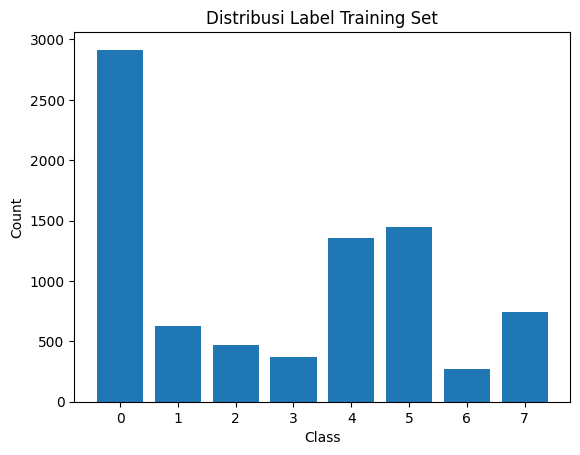

In [25]:
from collections import Counter
import matplotlib.pyplot as plt

# Hitung distribusi label di training set
class_counts = Counter(train_labels)
print("Distribusi label di training set:", class_counts)

# Kalau mau persentase
total = sum(class_counts.values())
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} ({count/total:.2%})")

# Visualisasi distribusi label
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Distribusi Label Training Set")
plt.show()


In [ ]:
# Lightning model
lit_model = MicroExpClassifier(model=model, lr=LEARNING_RATE, num_classes=NUM_CLASSES)

torch.set_float32_matmul_precision("medium")

logger = TensorBoardLogger("lightning_logs", name="convat_samm")
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=15,
    verbose=True,
    mode='min'
)

# trainer
trainer = L.Trainer(
    max_epochs=EPOCHS,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    log_every_n_steps=10,
    callbacks=[early_stop_callback],
    logger=logger,
)

# Run
trainer.fit(lit_model, train_loader, valid_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | ConVAT             | 2.0 M  | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
4 | test_acc  | MulticlassAccuracy | 0      | train
---------------------------------------------------------
2.0 M     Trainable params
0         Non-trainable params
2.0 M     Total params
8.105     Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 512/512 [01:03<00:00,  8.09it/s, v_num=7, val_loss=2.430, val_acc=0.142, train_loss=2.150, train_acc=0.168]

Metric val_loss improved. New best score: 2.428


Epoch 1: 100%|██████████| 512/512 [01:03<00:00,  8.09it/s, v_num=7, val_loss=1.990, val_acc=0.239, train_loss=1.990, train_acc=0.203]

Metric val_loss improved by 0.435 >= min_delta = 0.0. New best score: 1.992


...

Epoch 27: 100%|██████████| 512/512 [01:03<00:00,  8.04it/s, v_num=7, val_loss=0.458, val_acc=0.802, train_loss=0.467, train_acc=0.820]

Metric val_loss improved by 0.076 >= min_delta = 0.0. New best score: 0.458


Epoch 29: 100%|██████████| 512/512 [01:03<00:00,  8.04it/s, v_num=7, val_loss=0.665, val_acc=0.714, train_loss=0.441, train_acc=0.830]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 512/512 [01:03<00:00,  8.03it/s, v_num=7, val_loss=0.665, val_acc=0.714, train_loss=0.441, train_acc=0.830]


In [ ]:
trainer.test(lit_model, dataloaders=test_loader)

trainer.save_checkpoint("checkpoints/convat-1-last.ckpt")

In [28]:
def evaluate_model(model, dataloader, device):
    model = model.to(device)
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            scores = model(images)
            preds = scores.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Validation Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    return acc, cm

In [29]:
acc, cm = evaluate_model(lit_model, valid_loader, DEVICE)

Validation Accuracy: 0.7139
Confusion Matrix:
[[393  57   0  20  30  25  57  37]
 [  4  87   0   0   0   0  13  29]
 [  0   0 100   0   0   0   0   0]
 [  2   0   0  66   0   0   0  11]
 [  8  40   6   0 217   1   0  16]
 [  5   0   7  21  23 228  20   5]
 [  0   0   0  11   0   0  47   0]
 [  0   4   0  14  10   0  23 107]]
